## Análisis multivariable

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore') # Para evitar advertencias visuales en consola

In [13]:
#Cargar datos
# 1. Cargar el dataset (usamos sep=';')
df = pd.read_csv('data/data.csv', sep=';')

# 2. Convertir la columna de tiempo a formato DateTime y establecerla como índice
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d.%m.%Y %H:%M')
df.set_index('timestamp', inplace=True)

# 3. Seleccionar las variables del par Norte Este (NE)
co2_col = 'V005_vent01_CO2'
temp_col = 'V006_vent01_temp_out'

# Asegurar que sean numéricas y quitar valores nulos
df[co2_col] = pd.to_numeric(df[co2_col], errors='coerce')
df[temp_col] = pd.to_numeric(df[temp_col], errors='coerce')
df_pair = df[[co2_col, temp_col]].dropna()

print("//DATASET Norte - Este//")
df_pair.head()

//DATASET Norte - Este//


,V005_vent01_CO2,V006_vent01_temp_out
timestamp,,
2012-06-23 01:00:00,494.172532,22.700000
2012-06-23 02:00:00,491.992574,22.700000
2012-06-23 03:00:00,490.003467,22.628444
2012-06-23 04:00:00,490.972327,22.600000
2012-06-23 05:00:00,489.132106,22.600000


In [12]:
print("//DATASET ORIGINAL//")
df.head()

//DATASET ORIGINAL//


,V005_vent01_CO2,V022_vent02_CO2,V006_vent01_temp_out,V023_vent02_temp_out
timestamp,,,,
2012-06-23 01:00:00,494.172532,405.514287,22.700000,23.449972
2012-06-23 02:00:00,491.992574,404.705170,22.700000,23.400000
2012-06-23 03:00:00,490.003467,401.981443,22.628444,23.400000
2012-06-23 04:00:00,490.972327,402.471192,22.600000,23.400000
2012-06-23 05:00:00,489.132106,403.174487,22.600000,23.349972


In [5]:
# Extraer fecha (día) y hora
df_pair['date'] = df_pair.index.date
df_pair['hour'] = df_pair.index.hour

# Pivotear para tener 24 horas como columnas para cada variable
pivot_co2 = df_pair.pivot(index='date', columns='hour', values=co2_col)
pivot_temp = df_pair.pivot(index='date', columns='hour', values=temp_col)

# Eliminar los días que no tienen las 24 horas completas registradas
valid_dates = pivot_co2.dropna().index.intersection(pivot_temp.dropna().index)
pivot_co2 = pivot_co2.loc[valid_dates]
pivot_temp = pivot_temp.loc[valid_dates]

# Concatenar CO2 y Temperatura para crear el set de datos multivariable (48 características por día)
X_raw = pd.concat([pivot_co2, pivot_temp], axis=1)
X_raw.columns = [f'CO2_{h}' for h in range(24)] + [f'Temp_{h}' for h in range(24)]

# Escalar los datos (Z-score) porque el CO2 y la Temp tienen magnitudes muy distintas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

D. Encontrar patrones – análisis multivariable
De manera similar al literal B, encontrar los patrones diarios que existen en el data set,
para cada par de variables, es decir, las dos de la parte Norte Este y/o las dos de la parte
Sur Oeste. ¿Utilizar al menos dos técnicas para verificar su consistencia entre las dos
técnicas, existe algún patrón el más representativo?


Tamaños de clústeres K-Means: [np.int64(541), np.int64(384), np.int64(153)]
Tamaños de clústeres Jerárquico: [np.int64(527), np.int64(94), np.int64(457)]


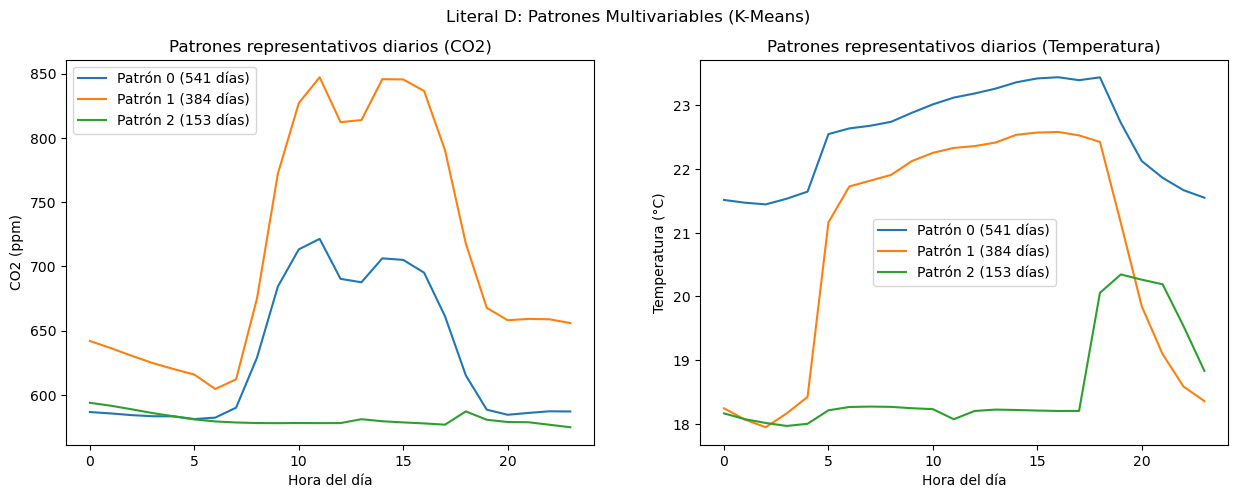

In [6]:
# --- Técnica 1: K-Means ---
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

# --- Técnica 2: Agglomerative Clustering (Jerárquico) ---
agglo = AgglomerativeClustering(n_clusters=3)
labels_agglo = agglo.fit_predict(X_scaled)

# Imprimir la cantidad de días asignados a cada clúster para verificar consistencia
print("Tamaños de clústeres K-Means:", [sum(labels_kmeans==i) for i in range(3)])
print("Tamaños de clústeres Jerárquico:", [sum(labels_agglo==i) for i in range(3)])

# --- Graficar los patrones encontrados por K-Means ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i in range(3):
    # Filtrar los datos de cada clúster
    cluster_data_co2 = pivot_co2[labels_kmeans == i]
    cluster_data_temp = pivot_temp[labels_kmeans == i]
    
    # Graficar el promedio (centroide) del clúster
    axes[0].plot(cluster_data_co2.mean(axis=0), label=f'Patrón {i} ({len(cluster_data_co2)} días)')
    axes[1].plot(cluster_data_temp.mean(axis=0), label=f'Patrón {i} ({len(cluster_data_temp)} días)')

axes[0].set_title('Patrones representativos diarios (CO2)')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('CO2 (ppm)')
axes[0].legend()

axes[1].set_title('Patrones representativos diarios (Temperatura)')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].legend()

plt.suptitle('Literal D: Patrones Multivariables (K-Means)')
plt.show()

E. Encontrar anomalías – análisis multivariable
3
De manera similar al literal C, encontrar anomalías, pero de los dos pares de variables.



Se encontraron 33 días anómalos.
Primeras 5 fechas anómalas: ['2012-06-24', '2012-07-01', '2012-07-14', '2012-07-15', '2012-07-21']


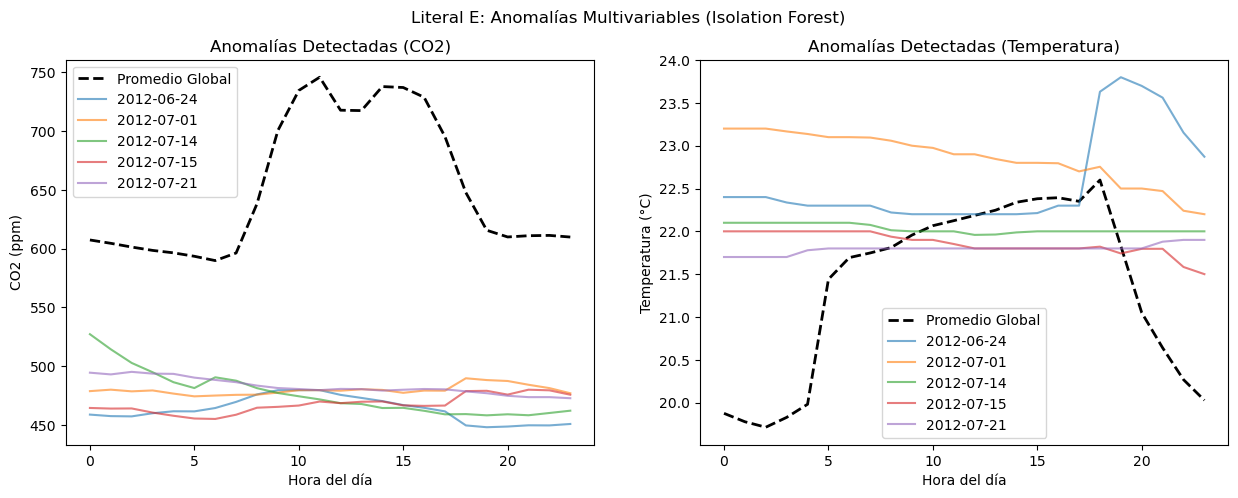

In [7]:
# Configurar Isolation Forest para detectar un 3% de anomalías (puedes ajustar este valor)
iso_forest = IsolationForest(contamination=0.03, random_state=42)
anomalies = iso_forest.fit_predict(X_scaled)

# Las anomalías se marcan con -1
anomaly_dates = X_raw.index[anomalies == -1]
print(f"\nSe encontraron {len(anomaly_dates)} días anómalos.")
print("Primeras 5 fechas anómalas:", [str(d) for d in anomaly_dates[:5]])

# --- Graficar las anomalías vs el comportamiento normal ---
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))

# Graficar el Promedio Global como referencia (línea negra punteada)
axes2[0].plot(pivot_co2.mean(axis=0), 'k--', label='Promedio Global', linewidth=2)
axes2[1].plot(pivot_temp.mean(axis=0), 'k--', label='Promedio Global', linewidth=2)

# Graficar los primeros 5 días anómalos detectados
for date in anomaly_dates[:5]:
    axes2[0].plot(pivot_co2.loc[date], alpha=0.6, label=str(date))
    axes2[1].plot(pivot_temp.loc[date], alpha=0.6, label=str(date))

axes2[0].set_title('Anomalías Detectadas (CO2)')
axes2[0].set_xlabel('Hora del día')
axes2[0].set_ylabel('CO2 (ppm)')
axes2[0].legend()

axes2[1].set_title('Anomalías Detectadas (Temperatura)')
axes2[1].set_xlabel('Hora del día')
axes2[1].set_ylabel('Temperatura (°C)')
axes2[1].legend()

plt.suptitle('Literal E: Anomalías Multivariables (Isolation Forest)')
plt.show()

F. Basados en el análisis conjunto (multivariable) de los patrones y anomalías, podemos sugerir lo siguiente:

Sobre los Patrones (Clústeres): Los patrones reflejan claramente los ciclos de ocupación y la dinámica térmica del edificio. El patrón principal (que abarca casi la mitad de los datos) sugiere los días laborables normales, donde el metabolismo humano y el uso de equipos aumentan el CO2 y el calor en las oficinas. Los patrones planos sugieren fines de semana o vacaciones, donde el sistema de ventilación o bien está apagado o en un régimen mínimo, y la temperatura responde principalmente a la inercia térmica exterior.

Sobre las Anomalías: La detección multivariable nos ayuda a sugerir fallos mecánicos o eventos extraordinarios. Un día clasificado como anómalo por Isolation Forest nos puede indicar:

Fallas en el sistema de ventilación (HVAC): Si la temperatura sube y el CO2 no se disipa adecuadamente durante el día.

Uso atípico del edificio: Eventos masivos de personas en fines de semana, lo que generaría picos de CO2 sin el soporte habitual del sistema de aire acondicionado del horario normal.

Errores de los sensores: Días donde la lectura de temperatura o CO2 presenta ruido extremo de manera errática.